<a href="https://colab.research.google.com/github/Likhithavaddhi/Healthacare-analysis/blob/main/Healthcare_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Healthcare Analytics for Doctor Visits
# Data Analysis Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv('/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv')

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(5190, 13)


In [4]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [ ]:
df.tail()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [6]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [7]:
df.describe(include='object')

,gender,private,freepoor,freerepat,nchronic,lchronic
count,5190,5190,5190,5190,5190,5190
unique,2,2,2,2,2,2
top,female,no,no,no,no,no
freq,2702,2892,4968,4099,3098,4585


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5190
Number of columns: 13


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)


Missing values in each column:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_summary

,Missing Values,Percentage
Unnamed: 0,0,0.0
visits,0,0.0
gender,0,0.0
age,0,0.0
income,0,0.0
illness,0,0.0
reduced,0,0.0
health,0,0.0
private,0,0.0
freepoor,0,0.0


In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5190, 13)


In [13]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print("Updated columns:")
print(df.columns.tolist())

Updated columns:
['visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


In [14]:
for column in df.columns:
    print("\n", "="*50)
    print("COLUMN:", column)
    print(df[column].value_counts().head(20))


COLUMN: visits
visits
0    4141
1     782
2     174
3      30
4      24
7      12
6      12
5       9
8       5
9       1
Name: count, dtype: int64

COLUMN: gender
gender
female    2702
male      2488
Name: count, dtype: int64

COLUMN: age
age
0.22    1213
0.72     822
0.19     752
0.27     523
0.62     316
0.67     315
0.32     301
0.57     273
0.52     222
0.47     181
0.37     146
0.42     126
Name: count, dtype: int64

COLUMN: income
income
0.25    1195
0.90     589
0.55     467
0.35     462
0.65     455
0.75     441
0.45     400
1.10     361
0.15     249
1.50     215
1.30     162
0.06      80
0.00      79
0.01      35
Name: count, dtype: int64

COLUMN: illness
illness
1    1638
0    1554
2     946
3     542
4     274
5     236
Name: count, dtype: int64

COLUMN: reduced
reduced
0     4454
14     188
1      177
2      108
3       74
4       45
5       40
7       38
6       17
8       17
10      12
9        7
12       6
13       5
11       2
Name: count, dtype: int64

COLUMN: health

In [16]:
print("Doctor Visit Statistics")
print("-----------------------")
print("Total visits:", df['visits'].sum())
print("Average visits:", round(df['visits'].mean(), 2))
print("Minimum visits:", df['visits'].min())
print("Maximum visits:", df['visits'].max())
print("Median visits:", df['visits'].median())

Doctor Visit Statistics
-----------------------
Total visits: 1566
Average visits: 0.3
Minimum visits: 0
Maximum visits: 9
Median visits: 0.0


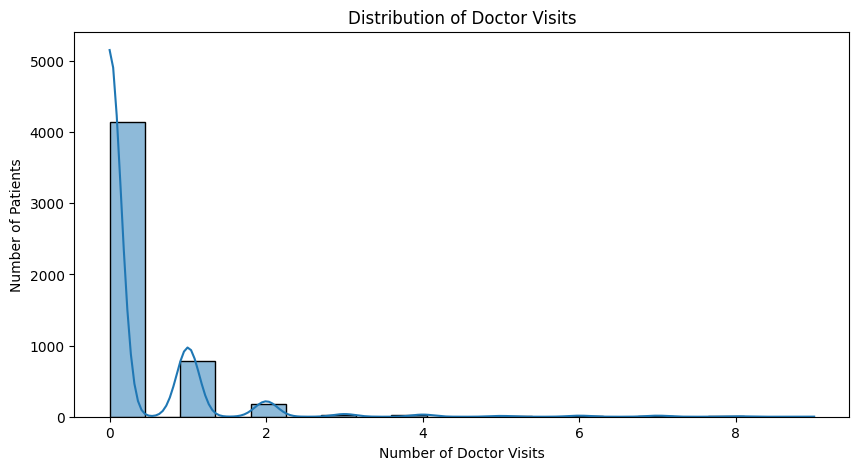

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='visits',
    bins=20,
    kde=True
)

plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Doctor Visits')
plt.ylabel('Number of Patients')

plt.show()

In [18]:
visit_counts = df['visits'].value_counts().sort_index()

print(visit_counts)

visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64


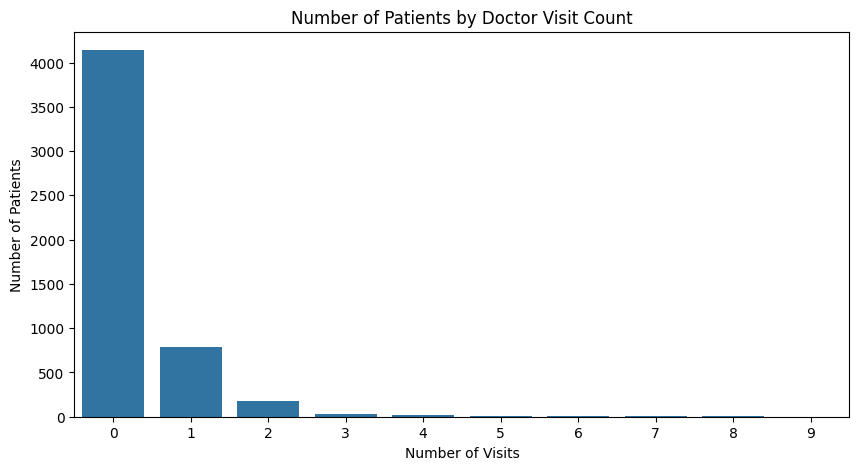

In [19]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=visit_counts.index,
    y=visit_counts.values
)

plt.title('Number of Patients by Doctor Visit Count')
plt.xlabel('Number of Visits')
plt.ylabel('Number of Patients')

plt.show()

In [20]:
healthcare_kpis = pd.DataFrame({
    'KPI': [
        'Total Patient Records',
        'Total Doctor Visits',
        'Average Visits per Patient',
        'Maximum Visits by a Patient',
        'Minimum Visits by a Patient'
    ],
    'Value': [
        len(df),
        df['visits'].sum(),
        round(df['visits'].mean(), 2),
        df['visits'].max(),
        df['visits'].min()
    ]
})

healthcare_kpis

,KPI,Value
0,Total Patient Records,5190.0
1,Total Doctor Visits,1566.0
2,Average Visits per Patient,0.3
3,Maximum Visits by a Patient,9.0
4,Minimum Visits by a Patient,0.0


In [21]:
gender_analysis = df.groupby('gender').agg(
    Patient_Count=('gender', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

gender_analysis

,gender,Patient_Count,Total_Visits,Average_Visits
0,female,2702,978,0.361954
1,male,2488,588,0.236334


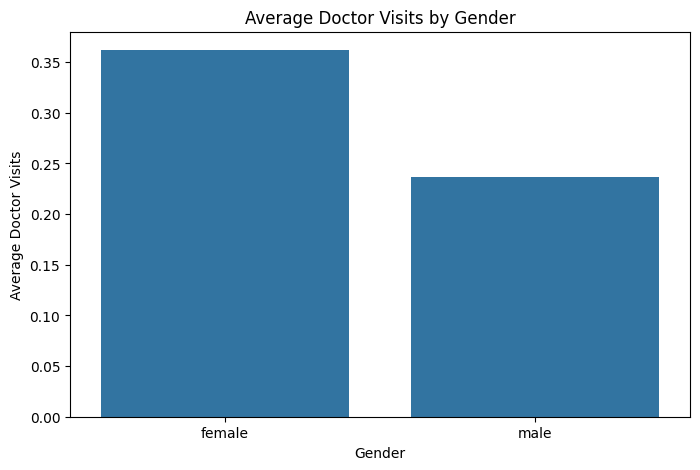

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_analysis,
    x='gender',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Doctor Visits')

plt.show()

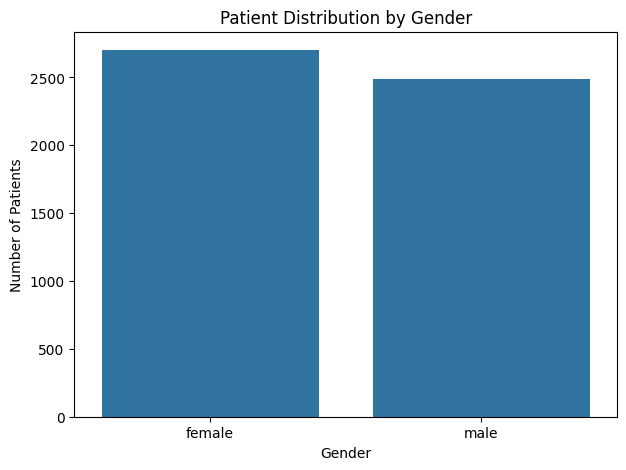

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='gender'
)

plt.title('Patient Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')

plt.show()

In [24]:
print("Unique age values:")
print(sorted(df['age'].unique()))

Unique age values:
[np.float64(0.19), np.float64(0.22), np.float64(0.27), np.float64(0.32), np.float64(0.37), np.float64(0.42), np.float64(0.47), np.float64(0.52), np.float64(0.57), np.float64(0.62), np.float64(0.67), np.float64(0.72)]


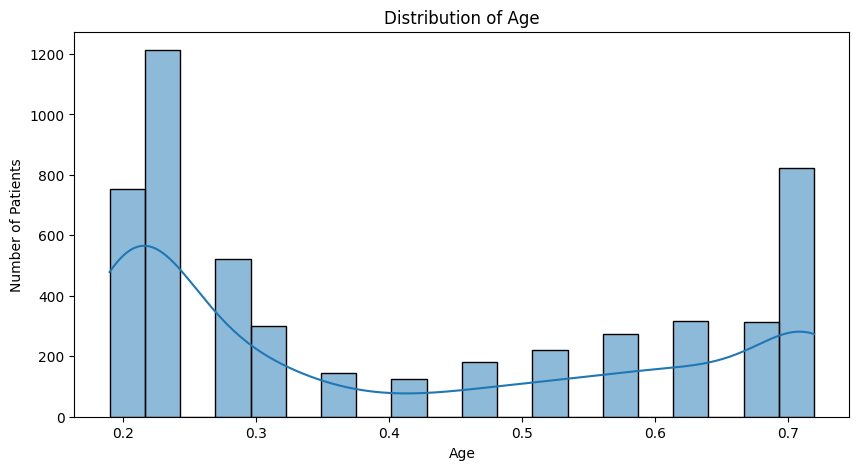

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True
)

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')

plt.show()

In [26]:
age_analysis = df.groupby('age').agg(
    Patient_Count=('age', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

age_analysis

,age,Patient_Count,Total_Visits,Average_Visits
0,0.19,752,160,0.212766
1,0.22,1213,244,0.201154
2,0.27,523,135,0.258126
3,0.32,301,73,0.242525
4,0.37,146,36,0.246575
5,0.42,126,40,0.317460
6,0.47,181,49,0.270718
7,0.52,222,92,0.414414
8,0.57,273,109,0.399267
9,0.62,316,112,0.354430


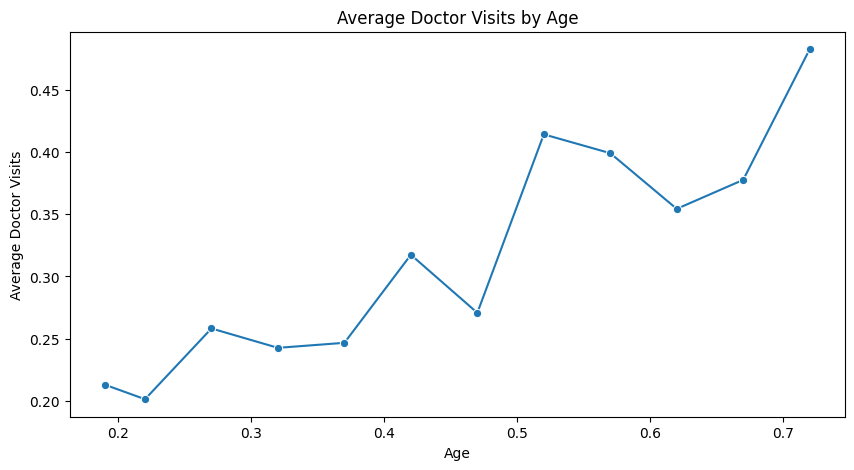

In [27]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=age_analysis,
    x='age',
    y='Average_Visits',
    marker='o'
)

plt.title('Average Doctor Visits by Age')
plt.xlabel('Age')
plt.ylabel('Average Doctor Visits')

plt.show()

In [28]:
print("Income Statistics")
print("-----------------")
print("Minimum:", df['income'].min())
print("Maximum:", df['income'].max())
print("Average:", round(df['income'].mean(), 2))
print("Median:", df['income'].median())

Income Statistics
-----------------
Minimum: 0.0
Maximum: 1.5
Average: 0.58
Median: 0.55


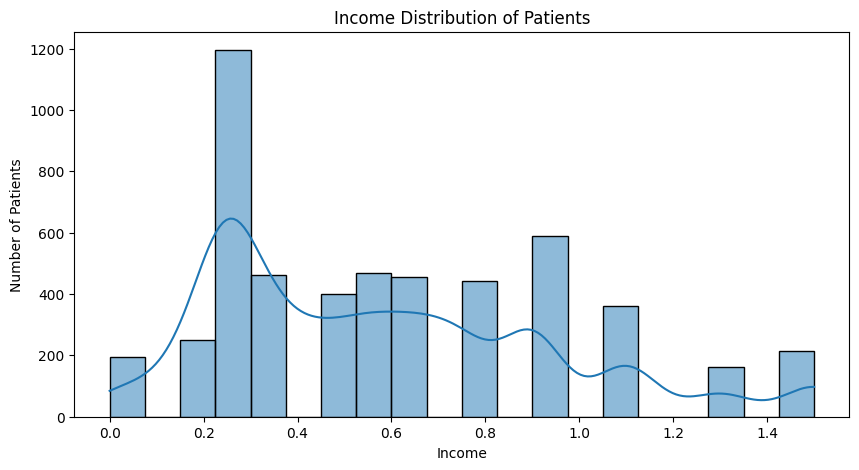

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='income',
    bins=20,
    kde=True
)

plt.title('Income Distribution of Patients')
plt.xlabel('Income')
plt.ylabel('Number of Patients')

plt.show()

In [30]:
income_analysis = df.groupby('income').agg(
    Patient_Count=('income', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

income_analysis.head(10)

,income,Patient_Count,Total_Visits,Average_Visits
0,0.00,79,29,0.367089
1,0.01,35,17,0.485714
2,0.06,80,16,0.200000
3,0.15,249,87,0.349398
4,0.25,1195,503,0.420921
5,0.35,462,166,0.359307
6,0.45,400,122,0.305000
7,0.55,467,118,0.252677
8,0.65,455,112,0.246154
9,0.75,441,108,0.244898


In [31]:
df['income_group'] = pd.qcut(
    df['income'],
    q=4,
    labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High']
)

df['income_group'].value_counts()

,count
income_group,
Low,1638
Upper-Middle,1485
Lower-Middle,1329
High,738


In [32]:
income_group_analysis = df.groupby(
    'income_group',
    observed=False
).agg(
    Patient_Count=('income_group', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

income_group_analysis

,income_group,Patient_Count,Total_Visits,Average_Visits
0,Low,1638,652,0.398046
1,Lower-Middle,1329,406,0.305493
2,Upper-Middle,1485,342,0.230303
3,High,738,166,0.224932


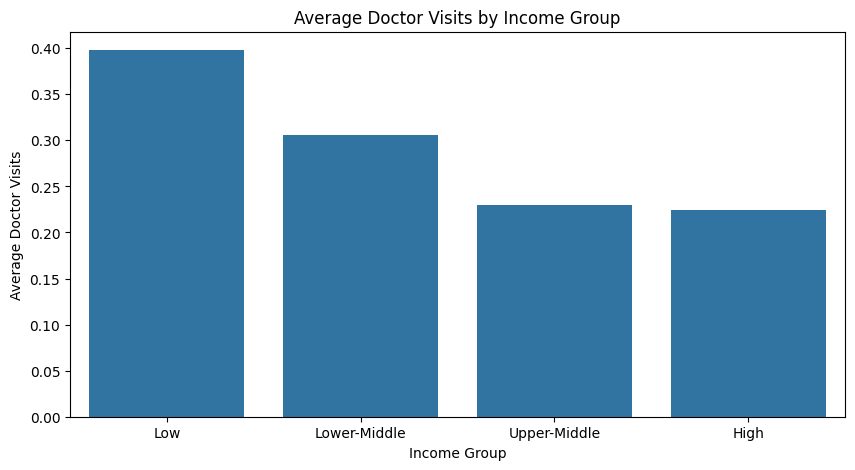

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=income_group_analysis,
    x='income_group',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Average Doctor Visits')

plt.show()

In [34]:
illness_analysis = df.groupby('illness').agg(
    Patient_Count=('illness', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

illness_analysis

,illness,Patient_Count,Total_Visits,Average_Visits
0,0,1554,122,0.078507
1,1,1638,484,0.295482
2,2,946,382,0.403805
3,3,542,228,0.420664
4,4,274,158,0.576642
5,5,236,192,0.813559


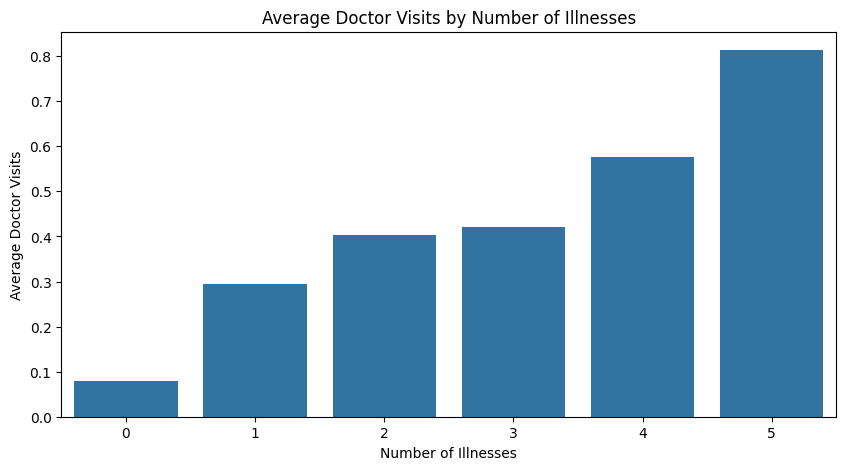

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=illness_analysis,
    x='illness',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Number of Illnesses')
plt.xlabel('Number of Illnesses')
plt.ylabel('Average Doctor Visits')

plt.show()

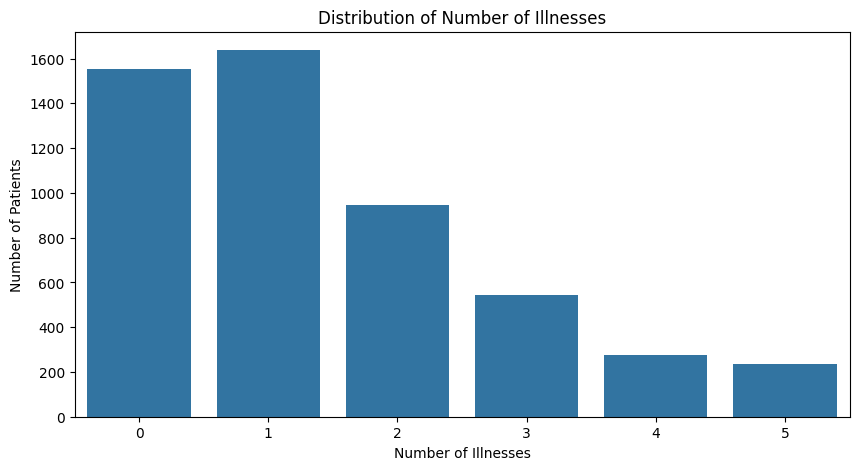

In [36]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='illness'
)

plt.title('Distribution of Number of Illnesses')
plt.xlabel('Number of Illnesses')
plt.ylabel('Number of Patients')

plt.show()

In [37]:
print("Health status values:")
print(df['health'].unique())

Health status values:
[ 1  0  9  2  6  5  7 11  4 12  3 10  8]


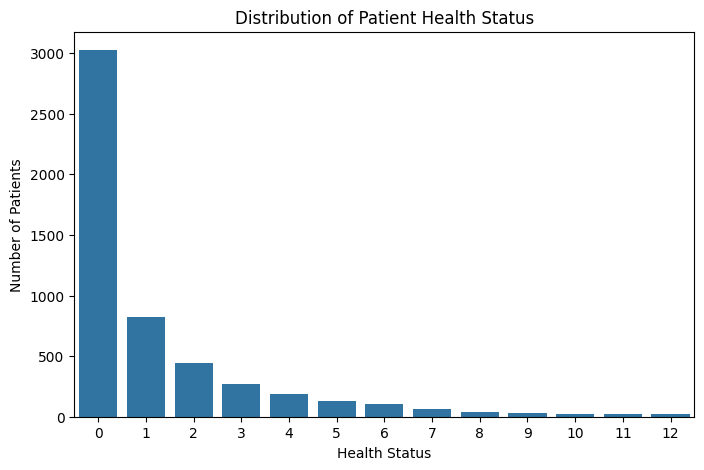

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='health'
)

plt.title('Distribution of Patient Health Status')
plt.xlabel('Health Status')
plt.ylabel('Number of Patients')

plt.show()

In [39]:
health_analysis = df.groupby('health').agg(
    Patient_Count=('health', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean'),
    Average_Illness=('illness', 'mean')
).reset_index()

health_analysis

,health,Patient_Count,Total_Visits,Average_Visits,Average_Illness
0,0,3026,603,0.199273,1.020159
1,1,823,276,0.335358,1.616039
2,2,446,170,0.381166,1.950673
3,3,273,114,0.417582,2.300366
4,4,187,100,0.534759,2.058824
5,5,132,70,0.530303,2.424242
6,6,104,65,0.625000,2.461538
7,7,61,56,0.918033,2.704918
8,8,42,20,0.476190,2.500000
9,9,32,21,0.656250,3.312500


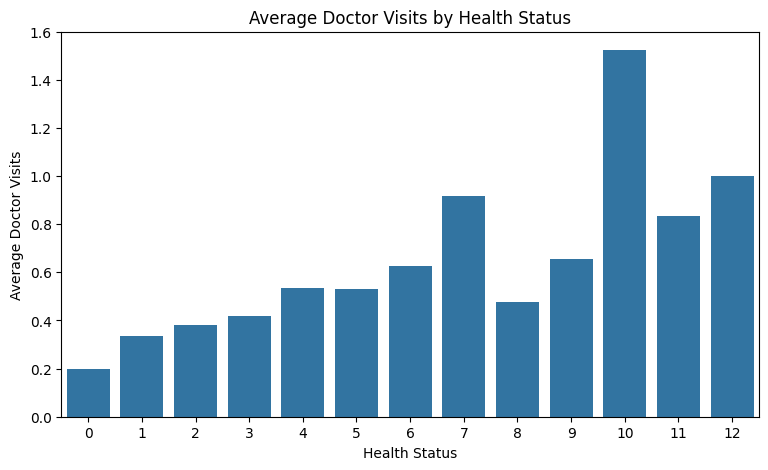

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=health_analysis,
    x='health',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Health Status')
plt.xlabel('Health Status')
plt.ylabel('Average Doctor Visits')

plt.show()

In [41]:
print("Reduced activity statistics:")
print(df['reduced'].describe())

Reduced activity statistics:
count    5190.000000
mean        0.861850
std         2.887628
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.000000
Name: reduced, dtype: float64


In [42]:
reduced_analysis = df.groupby('reduced').agg(
    Patient_Count=('reduced', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

reduced_analysis.head(20)

,reduced,Patient_Count,Total_Visits,Average_Visits
0,0,4454,819,0.183880
1,1,177,63,0.355932
2,2,108,62,0.574074
3,3,74,81,1.094595
4,4,45,36,0.800000
5,5,40,51,1.275000
6,6,17,20,1.176471
7,7,38,45,1.184211
8,8,17,20,1.176471
9,9,7,12,1.714286


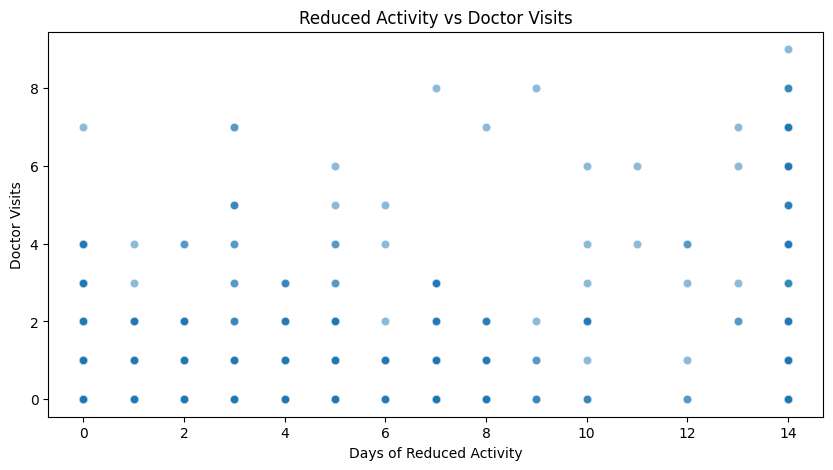

In [43]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='reduced',
    y='visits',
    alpha=0.5
)

plt.title('Reduced Activity vs Doctor Visits')
plt.xlabel('Days of Reduced Activity')
plt.ylabel('Doctor Visits')

plt.show()

In [44]:
print(df['private'].value_counts())

private
no     2892
yes    2298
Name: count, dtype: int64


In [45]:
private_analysis = df.groupby('private').agg(
    Patient_Count=('private', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

private_analysis

,private,Patient_Count,Total_Visits,Average_Visits
0,no,2892,889,0.307400
1,yes,2298,677,0.294604


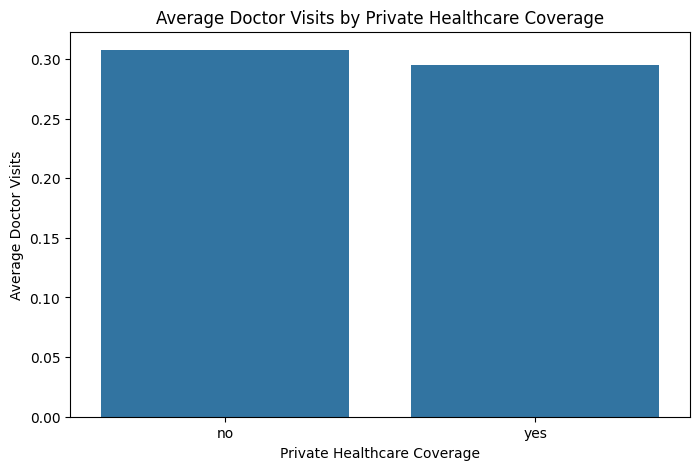

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=private_analysis,
    x='private',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Private Healthcare Coverage')
plt.xlabel('Private Healthcare Coverage')
plt.ylabel('Average Doctor Visits')

plt.show()

In [47]:
print(df['freepoor'].value_counts())

freepoor
no     4968
yes     222
Name: count, dtype: int64


In [48]:
freepoor_analysis = df.groupby('freepoor').agg(
    Patient_Count=('freepoor', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

freepoor_analysis

,freepoor,Patient_Count,Total_Visits,Average_Visits
0,no,4968,1531,0.308172
1,yes,222,35,0.157658


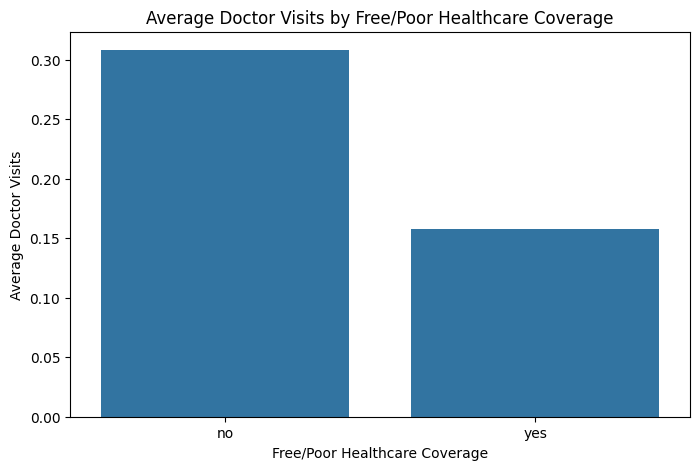

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=freepoor_analysis,
    x='freepoor',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Free/Poor Healthcare Coverage')
plt.xlabel('Free/Poor Healthcare Coverage')
plt.ylabel('Average Doctor Visits')

plt.show()

In [50]:
print(df['freerepat'].value_counts())

freerepat
no     4099
yes    1091
Name: count, dtype: int64


In [51]:
freerepat_analysis = df.groupby('freerepat').agg(
    Patient_Count=('freerepat', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

freerepat_analysis

,freerepat,Patient_Count,Total_Visits,Average_Visits
0,no,4099,1057,0.257868
1,yes,1091,509,0.466544


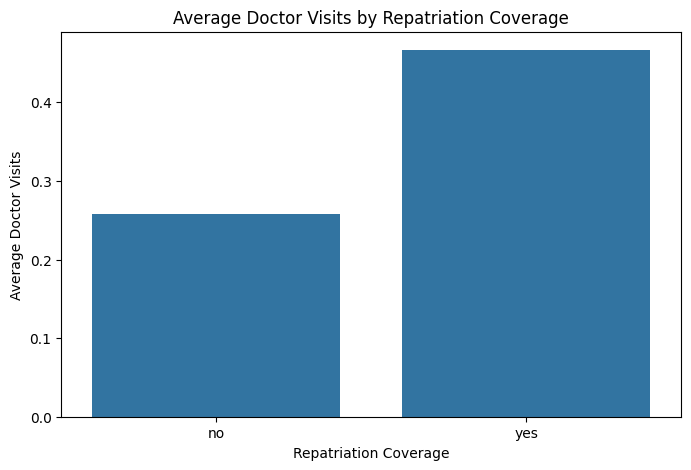

In [52]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=freerepat_analysis,
    x='freerepat',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Repatriation Coverage')
plt.xlabel('Repatriation Coverage')
plt.ylabel('Average Doctor Visits')

plt.show()

In [53]:
print(df['nchronic'].value_counts())

nchronic
no     3098
yes    2092
Name: count, dtype: int64


In [54]:
nchronic_analysis = df.groupby('nchronic').agg(
    Patient_Count=('nchronic', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

nchronic_analysis

,nchronic,Patient_Count,Total_Visits,Average_Visits
0,no,3098,843,0.272111
1,yes,2092,723,0.345602


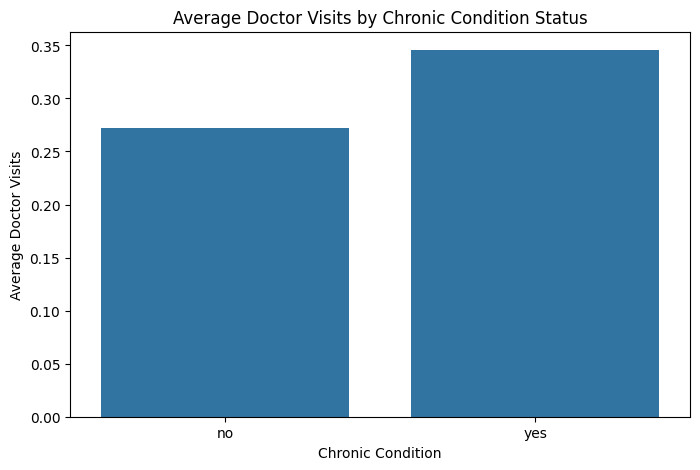

In [55]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=nchronic_analysis,
    x='nchronic',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Chronic Condition Status')
plt.xlabel('Chronic Condition')
plt.ylabel('Average Doctor Visits')

plt.show()

In [56]:
print(df['lchronic'].value_counts())

lchronic
no     4585
yes     605
Name: count, dtype: int64


In [57]:
lchronic_analysis = df.groupby('lchronic').agg(
    Patient_Count=('lchronic', 'count'),
    Total_Visits=('visits', 'sum'),
    Average_Visits=('visits', 'mean')
).reset_index()

lchronic_analysis

,lchronic,Patient_Count,Total_Visits,Average_Visits
0,no,4585,1201,0.261941
1,yes,605,365,0.603306


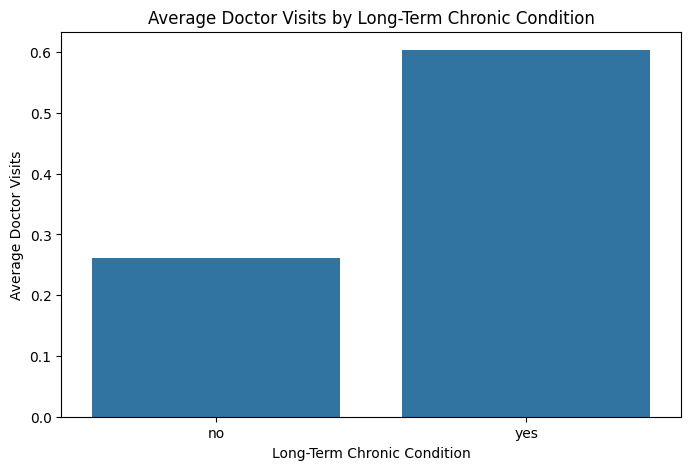

In [58]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=lchronic_analysis,
    x='lchronic',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Long-Term Chronic Condition')
plt.xlabel('Long-Term Chronic Condition')
plt.ylabel('Average Doctor Visits')

plt.show()

In [59]:
numerical_columns = [
    'visits',
    'age',
    'income',
    'illness',
    'reduced',
    'health'
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


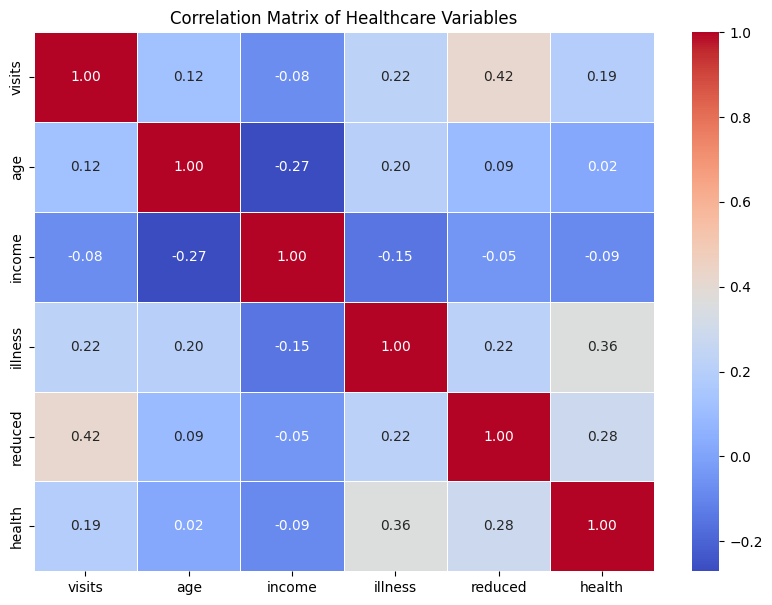

In [60]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Matrix of Healthcare Variables')
plt.show()

In [61]:
visit_correlation = (
    correlation_matrix['visits']
    .sort_values(ascending=False)
)

print("Correlation with Doctor Visits:")
print(visit_correlation)

Correlation with Doctor Visits:
visits     1.000000
reduced    0.418954
illness    0.223552
health     0.193272
age        0.124537
income    -0.076840
Name: visits, dtype: float64


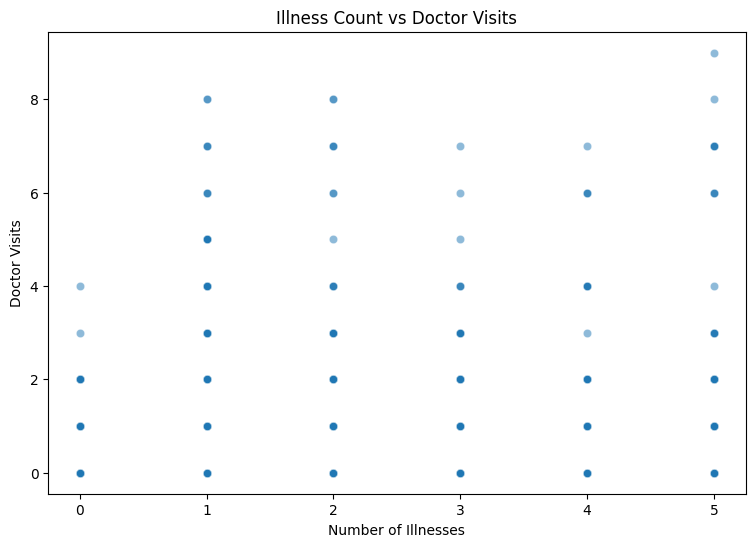

In [62]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='illness',
    y='visits',
    alpha=0.5
)

plt.title('Illness Count vs Doctor Visits')
plt.xlabel('Number of Illnesses')
plt.ylabel('Doctor Visits')

plt.show()

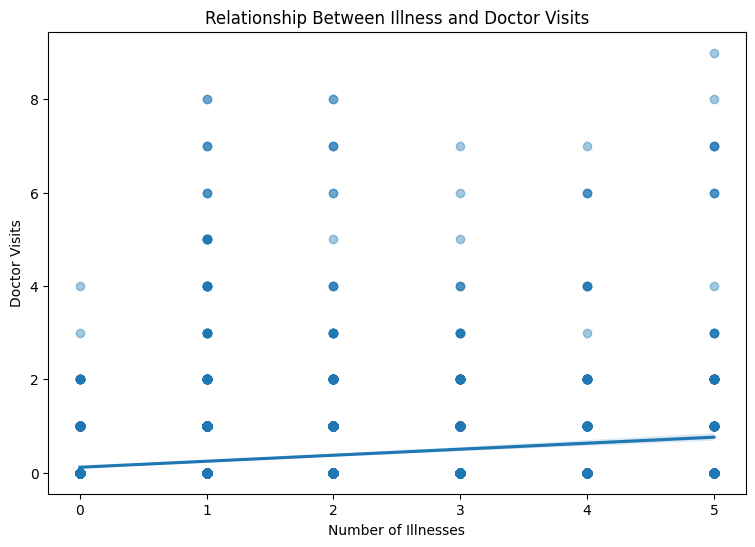

In [63]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x='illness',
    y='visits',
    scatter_kws={'alpha': 0.4},
    line_kws={}
)

plt.title('Relationship Between Illness and Doctor Visits')
plt.xlabel('Number of Illnesses')
plt.ylabel('Doctor Visits')

plt.show()

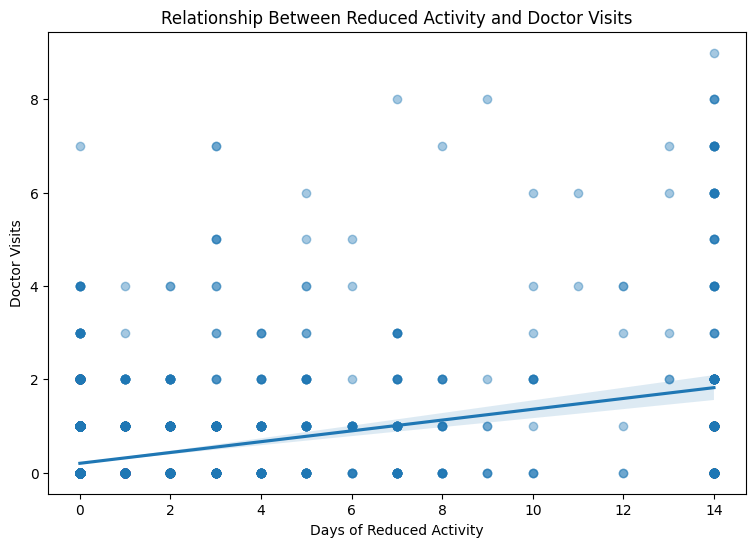

In [64]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x='reduced',
    y='visits',
    scatter_kws={'alpha': 0.4},
    line_kws={}
)

plt.title('Relationship Between Reduced Activity and Doctor Visits')
plt.xlabel('Days of Reduced Activity')
plt.ylabel('Doctor Visits')

plt.show()

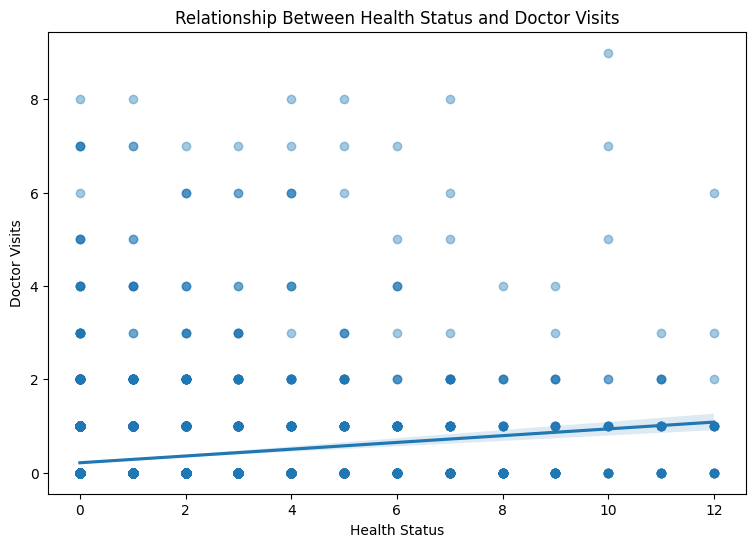

In [65]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x='health',
    y='visits',
    scatter_kws={'alpha': 0.4},
    line_kws={}
)

plt.title('Relationship Between Health Status and Doctor Visits')
plt.xlabel('Health Status')
plt.ylabel('Doctor Visits')

plt.show()

In [66]:
comparison = pd.DataFrame({
    'Gender': df.groupby('gender')['visits'].mean(),
    'Private Coverage': df.groupby('private')['visits'].mean(),
    'Free/Poor Coverage': df.groupby('freepoor')['visits'].mean(),
    'New Chronic Condition': df.groupby('nchronic')['visits'].mean(),
    'Long-Term Chronic Condition': df.groupby('lchronic')['visits'].mean()
})

comparison

,Gender,Private Coverage,Free/Poor Coverage,New Chronic Condition,Long-Term Chronic Condition
female,0.361954,NaN,NaN,NaN,NaN
male,0.236334,NaN,NaN,NaN,NaN
no,NaN,0.307400,0.308172,0.272111,0.261941
yes,NaN,0.294604,0.157658,0.345602,0.603306


In [67]:
print("Highest Average Visits")
print("======================")

print(
    "Gender:",
    gender_analysis.loc[
        gender_analysis['Average_Visits'].idxmax(),
        'gender'
    ]
)

print(
    "Age:",
    age_analysis.loc[
        age_analysis['Average_Visits'].idxmax(),
        'age'
    ]
)

print(
    "Income Group:",
    income_group_analysis.loc[
        income_group_analysis['Average_Visits'].idxmax(),
        'income_group'
    ]
)

print(
    "Illness Level:",
    illness_analysis.loc[
        illness_analysis['Average_Visits'].idxmax(),
        'illness'
    ]
)

print(
    "Health Status:",
    health_analysis.loc[
        health_analysis['Average_Visits'].idxmax(),
        'health'
    ]
)

Highest Average Visits
Gender: female
Age: 0.72
Income Group: Low
Illness Level: 5
Health Status: 10


In [68]:
key_findings = pd.DataFrame({
    'Analysis': [
        'Gender',
        'Age',
        'Income Group',
        'Illness',
        'Health Status'
    ],
    'Group': [
        gender_analysis.loc[
            gender_analysis['Average_Visits'].idxmax(),
            'gender'
        ],
        age_analysis.loc[
            age_analysis['Average_Visits'].idxmax(),
            'age'
        ],
        income_group_analysis.loc[
            income_group_analysis['Average_Visits'].idxmax(),
            'income_group'
        ],
        illness_analysis.loc[
            illness_analysis['Average_Visits'].idxmax(),
            'illness'
        ],
        health_analysis.loc[
            health_analysis['Average_Visits'].idxmax(),
            'health'
        ]
    ]
})

key_findings

,Analysis,Group
0,Gender,female
1,Age,0.72
2,Income Group,Low
3,Illness,5
4,Health Status,10


In [69]:
import os

results_folder = '/content/healthcare_analysis_results'

os.makedirs(results_folder, exist_ok=True)

print("Results folder created!")

Results folder created!


In [70]:
overall_summary = pd.DataFrame({
    'Metric': [
        'Total Patient Records',
        'Total Doctor Visits',
        'Average Doctor Visits',
        'Maximum Doctor Visits',
        'Minimum Doctor Visits'
    ],
    'Value': [
        len(df),
        df['visits'].sum(),
        df['visits'].mean(),
        df['visits'].max(),
        df['visits'].min()
    ]
})

overall_summary.to_csv(
    f'{results_folder}/overall_summary.csv',
    index=False
)

gender_analysis.to_csv(
    f'{results_folder}/gender_analysis.csv',
    index=False
)

age_analysis.to_csv(
    f'{results_folder}/age_analysis.csv',
    index=False
)

income_group_analysis.to_csv(
    f'{results_folder}/income_analysis.csv',
    index=False
)

illness_analysis.to_csv(
    f'{results_folder}/illness_analysis.csv',
    index=False
)

health_analysis.to_csv(
    f'{results_folder}/health_analysis.csv',
    index=False
)

correlation_matrix.to_csv(
    f'{results_folder}/correlation_matrix.csv'
)

key_findings.to_csv(
    f'{results_folder}/key_findings.csv',
    index=False
)

print("Analysis results saved successfully!")

Analysis results saved successfully!


In [71]:
print("========================================")
print("       HEALTHCARE ANALYTICS RESULTS")
print("========================================")

print("\nTotal Patient Records:", len(df))
print("Total Doctor Visits:", df['visits'].sum())
print("Average Doctor Visits:", round(df['visits'].mean(), 2))

print("\nKey Findings:")
display(key_findings)

print("\nCorrelation with Doctor Visits:")
display(visit_correlation)

       HEALTHCARE ANALYTICS RESULTS

Total Patient Records: 5190
Total Doctor Visits: 1566
Average Doctor Visits: 0.3

Key Findings:


,Analysis,Group
0,Gender,female
1,Age,0.72
2,Income Group,Low
3,Illness,5
4,Health Status,10



Correlation with Doctor Visits:


,visits
visits,1.000000
reduced,0.418954
illness,0.223552
health,0.193272
age,0.124537
income,-0.076840


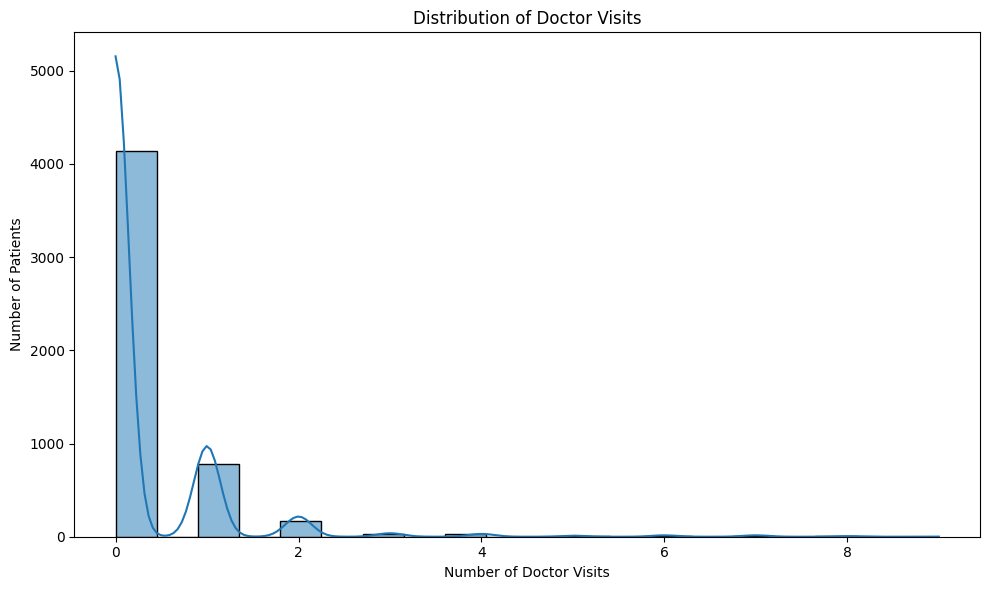

In [72]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='visits',
    bins=20,
    kde=True
)

plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Doctor Visits')
plt.ylabel('Number of Patients')

plt.tight_layout()
plt.show()

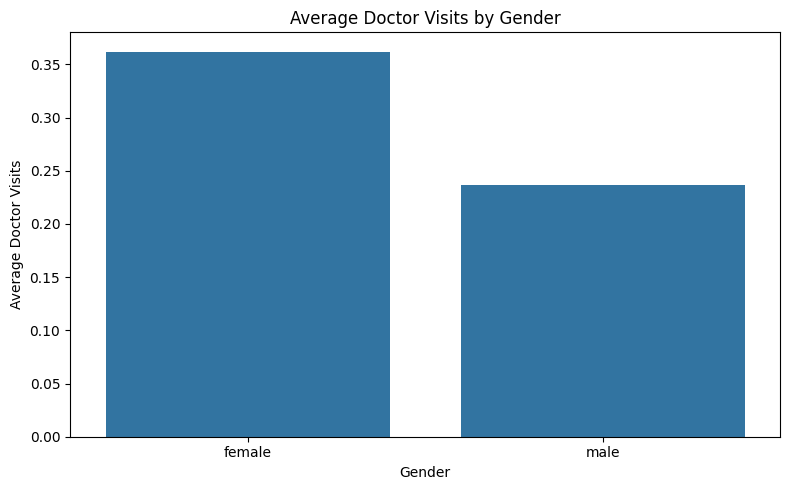

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_analysis,
    x='gender',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

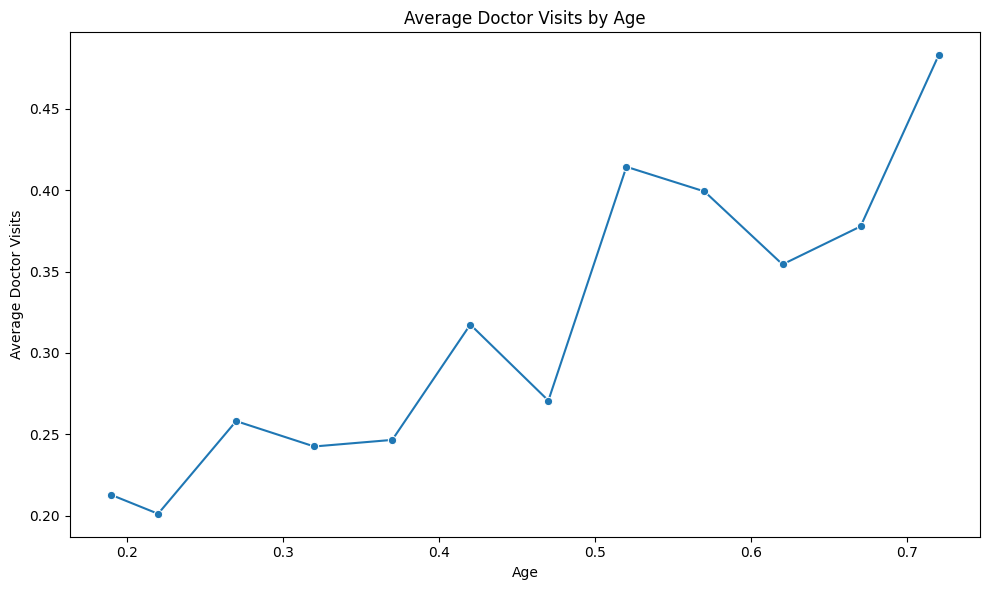

In [74]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=age_analysis,
    x='age',
    y='Average_Visits',
    marker='o'
)

plt.title('Average Doctor Visits by Age')
plt.xlabel('Age')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

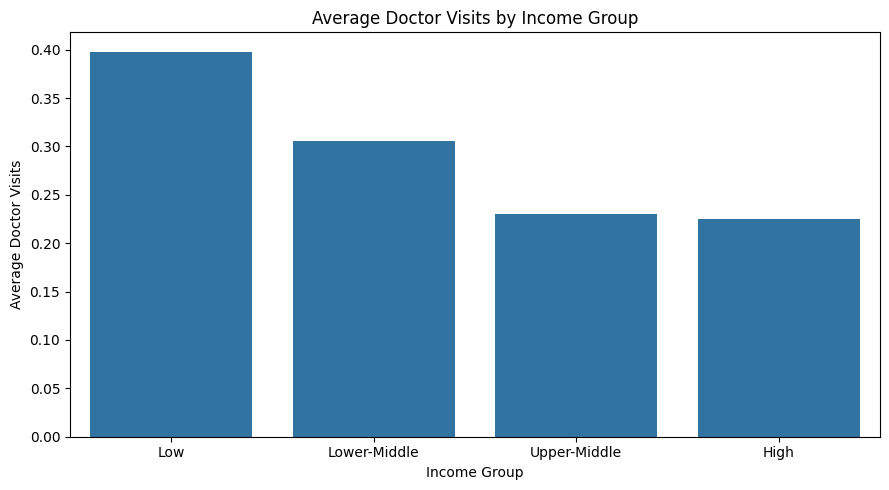

In [75]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=income_group_analysis,
    x='income_group',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

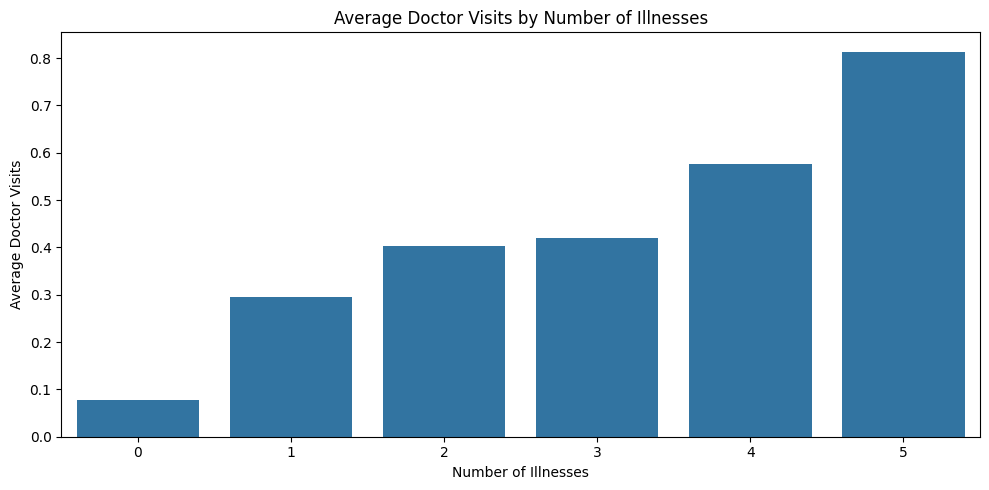

In [76]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=illness_analysis,
    x='illness',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Number of Illnesses')
plt.xlabel('Number of Illnesses')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

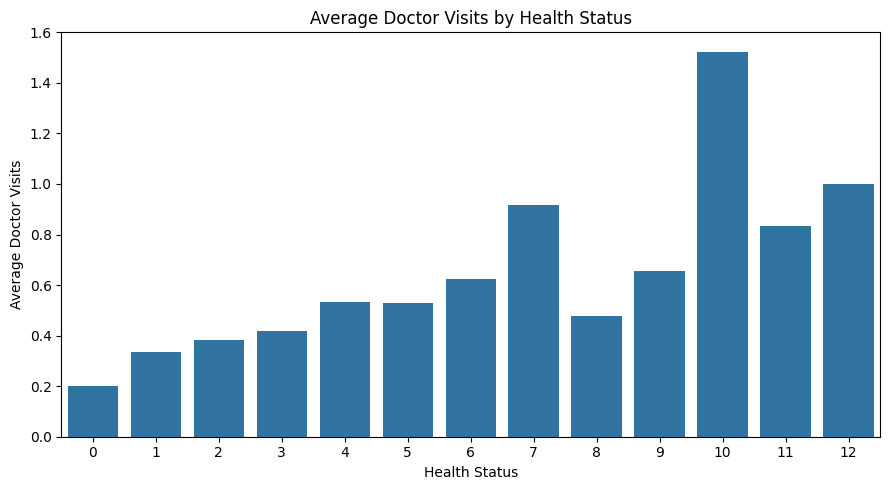

In [77]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=health_analysis,
    x='health',
    y='Average_Visits'
)

plt.title('Average Doctor Visits by Health Status')
plt.xlabel('Health Status')
plt.ylabel('Average Doctor Visits')

plt.tight_layout()
plt.show()

In [78]:
chronic_comparison = pd.DataFrame({
    'New Chronic Condition': df.groupby('nchronic')['visits'].mean(),
    'Long-Term Chronic Condition': df.groupby('lchronic')['visits'].mean()
})

chronic_comparison

,New Chronic Condition,Long-Term Chronic Condition
no,0.272111,0.261941
yes,0.345602,0.603306


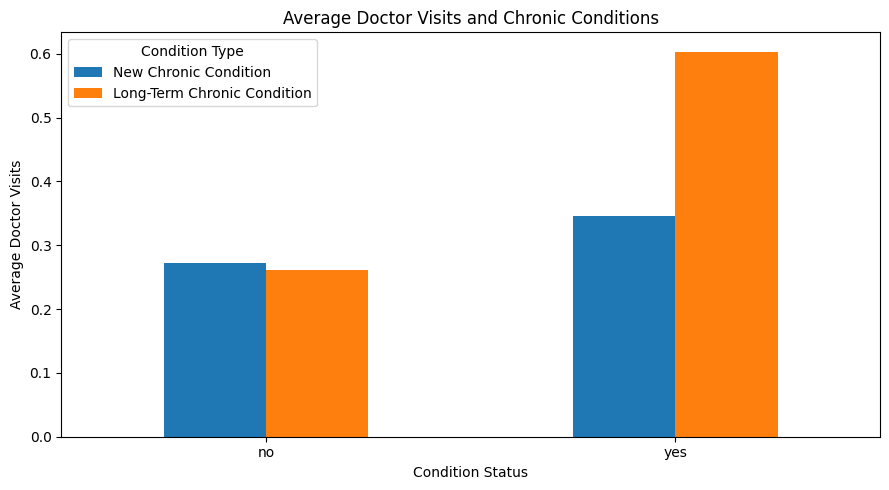

In [79]:
chronic_comparison.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Doctor Visits and Chronic Conditions')
plt.xlabel('Condition Status')
plt.ylabel('Average Doctor Visits')
plt.xticks(rotation=0)
plt.legend(title='Condition Type')

plt.tight_layout()
plt.show()

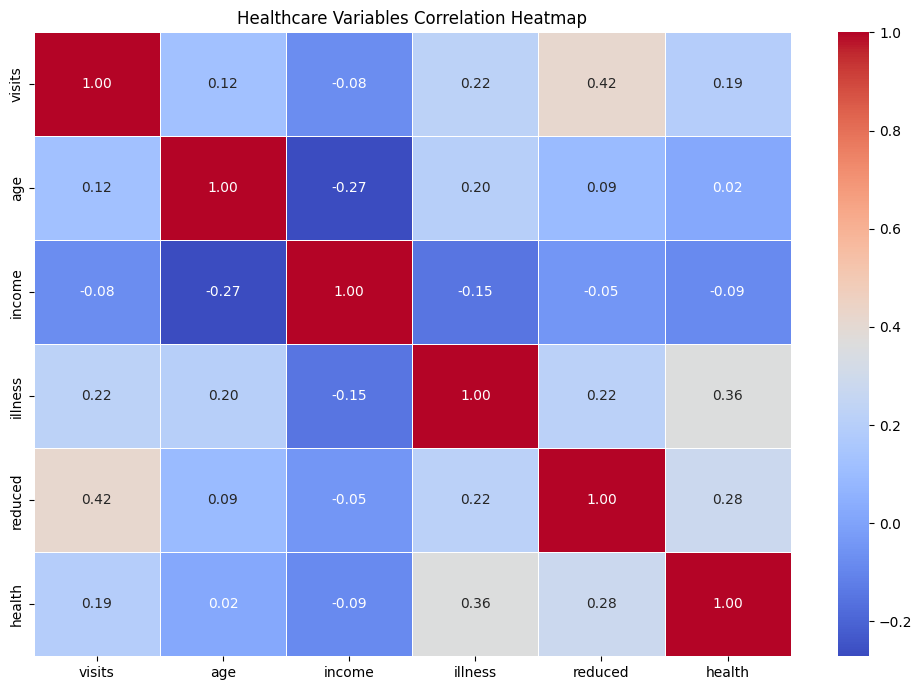

In [80]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Healthcare Variables Correlation Heatmap')

plt.tight_layout()
plt.show()

In [81]:
final_summary = pd.DataFrame({
    'Metric': [
        'Total Patient Records',
        'Total Doctor Visits',
        'Average Doctor Visits',
        'Maximum Doctor Visits',
        'Average Illness Count',
        'Average Reduced Activity'
    ],
    'Value': [
        len(df),
        df['visits'].sum(),
        round(df['visits'].mean(), 2),
        df['visits'].max(),
        round(df['illness'].mean(), 2),
        round(df['reduced'].mean(), 2)
    ]
})

final_summary

,Metric,Value
0,Total Patient Records,5190.00
1,Total Doctor Visits,1566.00
2,Average Doctor Visits,0.30
3,Maximum Doctor Visits,9.00
4,Average Illness Count,1.43
5,Average Reduced Activity,0.86


In [82]:
final_summary.to_csv(
    '/content/healthcare_analysis_results/final_summary.csv',
    index=False
)

print("Final summary saved successfully!")

Final summary saved successfully!


In [83]:
recommendations = pd.DataFrame({
    'Area': [
        'Doctor Visit Planning',
        'Patient Monitoring',
        'Chronic Conditions',
        'Healthcare Access',
        'Resource Allocation'
    ],
    'Recommendation': [
        'Use historical visit patterns to support appointment and staffing planning.',
        'Monitor groups with higher visit frequencies for appropriate follow-up and care coordination.',
        'Use chronic-condition patterns to support regular follow-up and preventive-care planning.',
        'Review healthcare coverage patterns to identify differences in healthcare utilization.',
        'Use demographic and utilization patterns to support efficient healthcare resource planning.'
    ]
})

recommendations

,Area,Recommendation
0,Doctor Visit Planning,Use historical visit patterns to support appoi...
1,Patient Monitoring,Monitor groups with higher visit frequencies f...
2,Chronic Conditions,Use chronic-condition patterns to support regu...
3,Healthcare Access,Review healthcare coverage patterns to identif...
4,Resource Allocation,Use demographic and utilization patterns to su...


In [84]:
recommendations.to_csv(
    '/content/healthcare_analysis_results/recommendations.csv',
    index=False
)

print("Recommendations saved successfully!")

Recommendations saved successfully!


In [85]:
import os

print("Files in results folder:")
for file in os.listdir('/content/healthcare_analysis_results'):
    print(file)

Files in results folder:
final_summary.csv
gender_analysis.csv
income_analysis.csv
overall_summary.csv
recommendations.csv
health_analysis.csv
age_analysis.csv
key_findings.csv
correlation_matrix.csv
illness_analysis.csv


In [86]:
print("========== FINAL PROJECT RESULTS ==========")

print("\n1. Overall Doctor Visits")
print("Total patients:", len(df))
print("Total doctor visits:", df['visits'].sum())
print("Average visits:", round(df['visits'].mean(), 2))

print("\n2. Gender Analysis")
display(gender_analysis)

print("\n3. Age Analysis")
display(age_analysis)

print("\n4. Income Group Analysis")
display(income_group_analysis)

print("\n5. Illness Analysis")
display(illness_analysis)

print("\n6. Health Status Analysis")
display(health_analysis)

print("\n7. Chronic Condition Analysis")
display(nchronic_analysis)
display(lchronic_analysis)

print("\n8. Correlation with Doctor Visits")
display(visit_correlation)

========== FINAL PROJECT RESULTS ==========

1. Overall Doctor Visits
Total patients: 5190
Total doctor visits: 1566
Average visits: 0.3

2. Gender Analysis


,gender,Patient_Count,Total_Visits,Average_Visits
0,female,2702,978,0.361954
1,male,2488,588,0.236334



3. Age Analysis


,age,Patient_Count,Total_Visits,Average_Visits
0,0.19,752,160,0.212766
1,0.22,1213,244,0.201154
2,0.27,523,135,0.258126
3,0.32,301,73,0.242525
4,0.37,146,36,0.246575
5,0.42,126,40,0.317460
6,0.47,181,49,0.270718
7,0.52,222,92,0.414414
8,0.57,273,109,0.399267
9,0.62,316,112,0.354430



4. Income Group Analysis


...


7. Chronic Condition Analysis


,nchronic,Patient_Count,Total_Visits,Average_Visits
0,no,3098,843,0.272111
1,yes,2092,723,0.345602


,lchronic,Patient_Count,Total_Visits,Average_Visits
0,no,4585,1201,0.261941
1,yes,605,365,0.603306



8. Correlation with Doctor Visits


,visits
visits,1.000000
reduced,0.418954
illness,0.223552
health,0.193272
age,0.124537
income,-0.076840
